In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file into a DataFrame
df = pd.read_csv('/content/RILO - Copy.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the DataFrame:")
display(df.head())

First 5 rows of the DataFrame:


,Symbol,Series,Date,Prev Close,Open Price,High Price,Low Price,Last Price,Close Price,Average Price,Total Traded Quantity,Turnover,No. of Trades,Deliverable Qty,% Dly Qt to Traded Qty
0,RELIANCE,EQ,01-Jan-16,1014.60,1009.80,1018.9,1008.20,1013.6,1015.35,1015.52,1238135,1.257353e+09,30701,529539,42.77
1,RELIANCE,EQ,04-Jan-16,1015.35,1005.00,1013.8,986.70,993.2,995.30,998.91,6896571,6.889070e+09,66235,4974602,72.13
2,RELIANCE,EQ,05-Jan-16,995.30,1000.30,1010.0,997.00,1005.0,1005.15,1003.41,3416459,3.428125e+09,59935,1987804,58.18
3,RELIANCE,EQ,06-Jan-16,1005.15,1007.60,1038.4,1000.40,1029.1,1032.20,1028.15,6116855,6.289073e+09,160947,2912662,47.62
4,RELIANCE,EQ,07-Jan-16,1032.20,1021.05,1028.0,1008.05,1018.9,1013.25,1016.73,4512219,4.587700e+09,105075,2474491,54.84


### Price Trend Over Time: 'Close Price'

This line chart displays the fluctuation of 'Close Price' over time, revealing overall trend patterns, volatility periods, and how the stock price changes throughout the dataset. Stock price fluctuates over time but shows overall trend patterns.

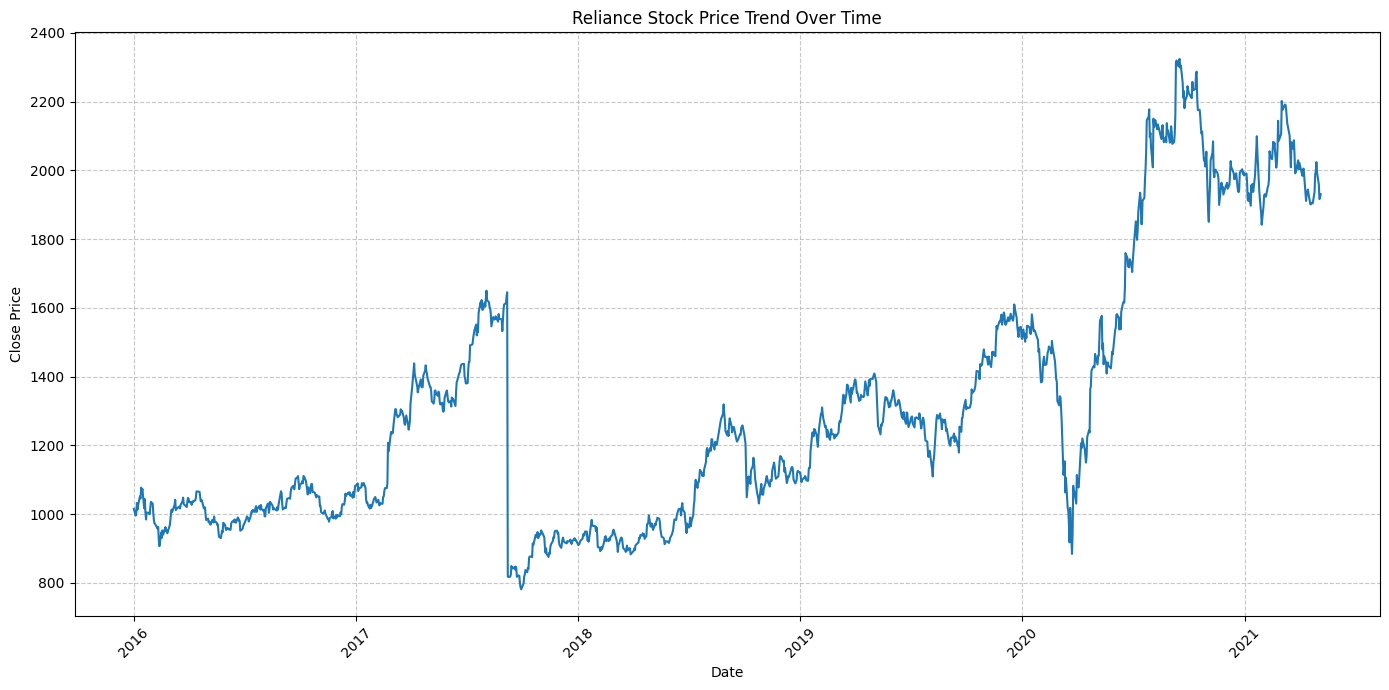

In [ ]:
# Convert 'Date' column to datetime objects if not already
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y')

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Close Price', data=df)
plt.title('Reliance Stock Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Daily Price Volatility

This area chart visualizes the daily price volatility, calculated as the difference between 'High Price' and 'Low Price'. Certain periods showing high volatility indicate market uncertainty.

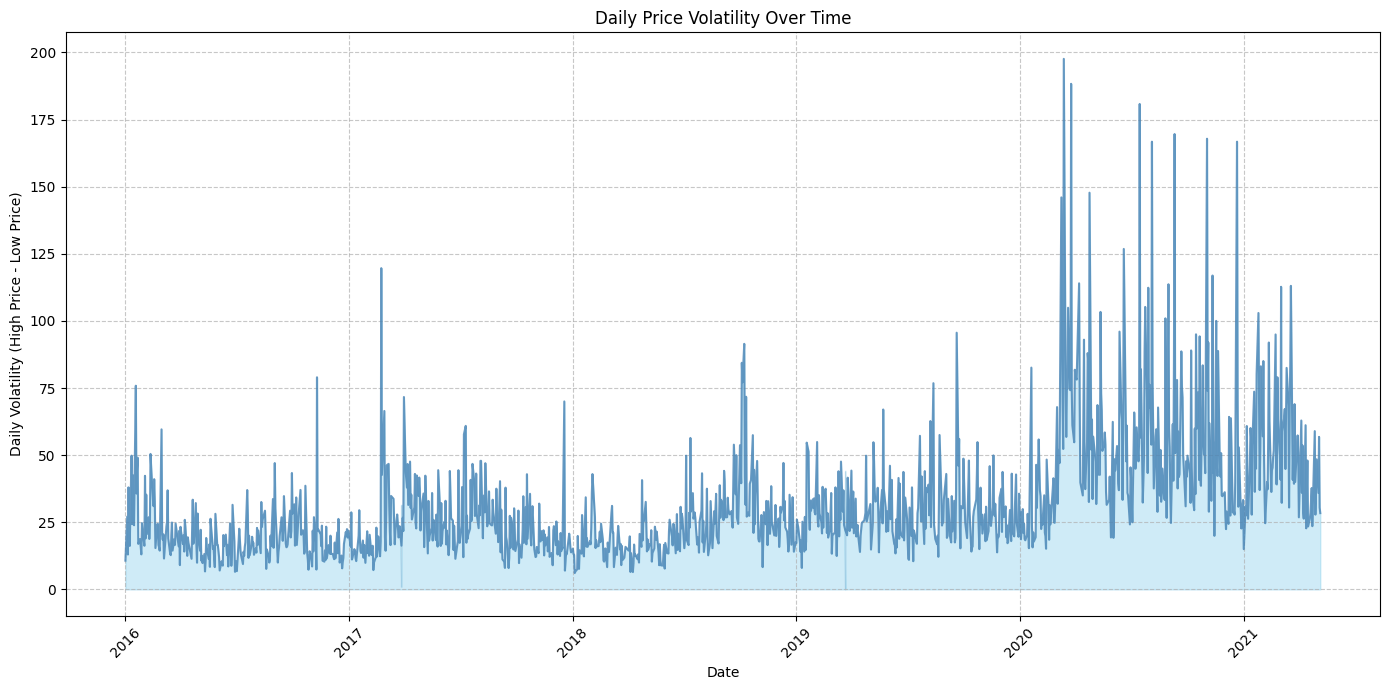

In [ ]:
# Calculate Daily Volatility
df['Daily Volatility'] = df['High Price'] - df['Low Price']

plt.figure(figsize=(14, 7))
plt.fill_between(df['Date'], df['Daily Volatility'], color='skyblue', alpha=0.4)
sns.lineplot(x='Date', y='Daily Volatility', data=df, color='steelblue', alpha=0.8)
plt.title('Daily Price Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Volatility (High Price - Low Price)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Trading Volume Distribution

This histogram displays the distribution of 'Total Traded Quantity', indicating that most trading days fall within a specific volume range. Trading activity is concentrated within a particular range.

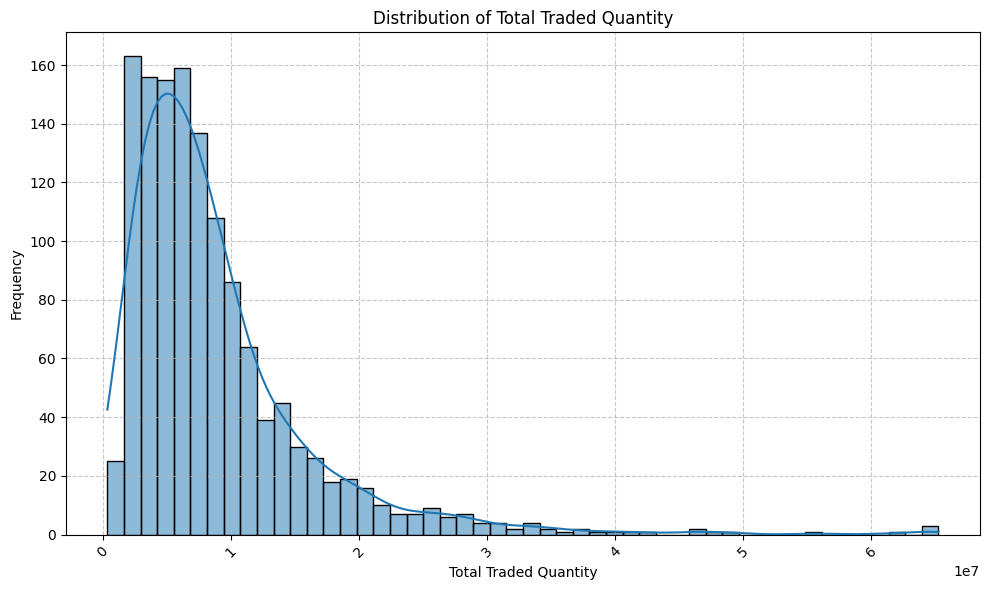

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Total Traded Quantity'], bins=50, kde=True)
plt.title('Distribution of Total Traded Quantity')
plt.xlabel('Total Traded Quantity')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Relationship Between Price & Volume

This scatter plot visualizes the relationship between 'Total Traded Quantity' and 'Close Price'. It helps to identify if higher trading volumes correlate with significant price movements, often indicating market interest or news-driven events.

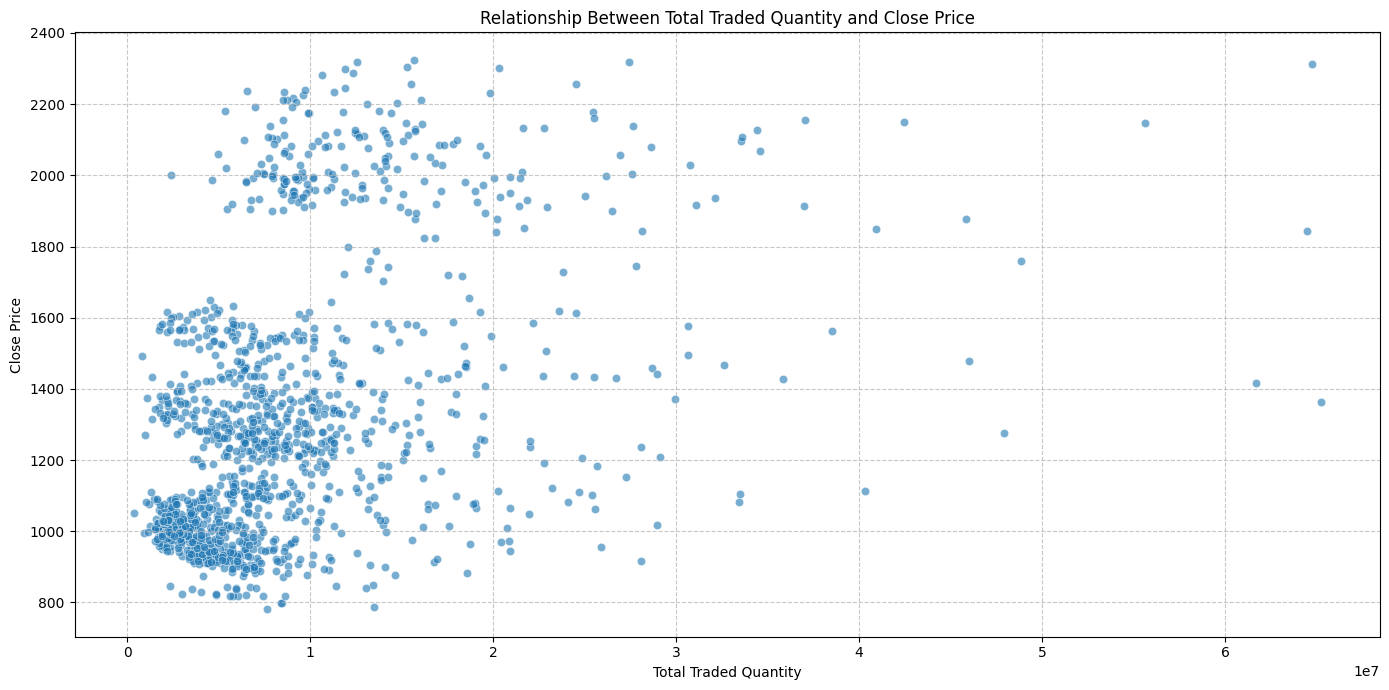

In [ ]:
plt.figure(figsize=(14, 7))
sns.scatterplot(x='Total Traded Quantity', y='Close Price', data=df, alpha=0.6)
plt.title('Relationship Between Total Traded Quantity and Close Price')
plt.xlabel('Total Traded Quantity')
plt.ylabel('Close Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Average Price vs Close Price

This dual line chart compares the 'Average Price' with the 'Close Price' over time, helping to visualize their relationship and identify if the closing price generally follows the average traded price closely.

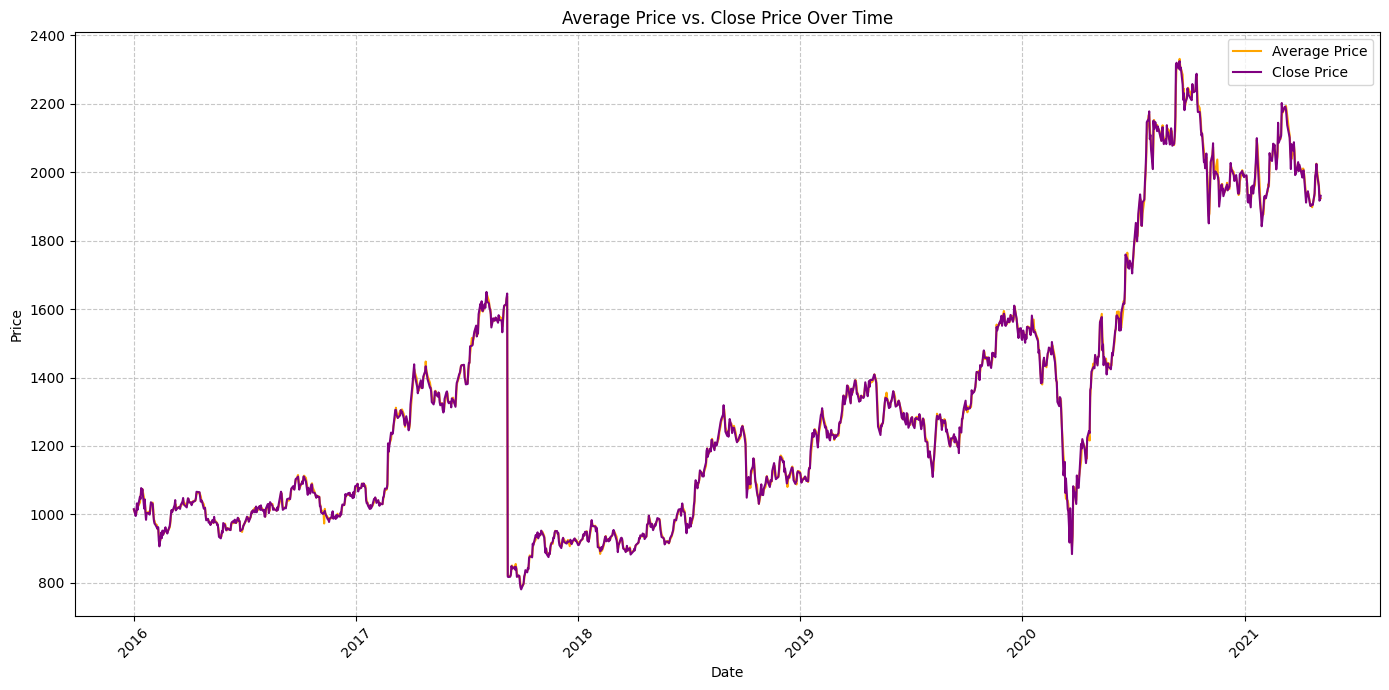

In [ ]:
# Calculate 'Average Price'
df['Average Price'] = (df['Open Price'] + df['High Price'] + df['Low Price'] + df['Close Price']) / 4

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Average Price', data=df, label='Average Price', color='orange')
sns.lineplot(x='Date', y='Close Price', data=df, label='Close Price', color='purple')
plt.title('Average Price vs. Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### 6. Daily Price Change Pattern

👉 **New Insight**: Analyze how much price changes daily

“Waterfall chart clearly shows cumulative gains and losses across trading days.”

👉 This gives a storytelling flow, not just static analysis.

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Ensure df is defined by running the data loading cell (17f58179) first.
# For demonstration purposes, if you want this cell to run standalone, you would add:
df = pd.read_csv('/content/RILO - Copy.csv')

df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

df = df.sort_values('Date')

df['Daily Change'] = df['Close Price'] - df['Open Price']

df = df.tail(30)

measure = ['relative'] * len(df)

fig = go.Figure(go.Waterfall(
    name="Daily Change",
    orientation="v",
    measure=measure,
    x=df['Date'].dt.strftime('%d-%b'),
    y=df['Daily Change'],

    increasing=dict(
        marker=dict(color='#00C853')
    ),

    decreasing=dict(
        marker=dict(color='#D50000')
    ),

    connector=dict(
        line=dict(color='rgba(63, 63, 63, 0.5)')
    )
))

fig.update_layout(
    title='RELIANCE Daily Price Change Pattern',
    title_x=0.5,
    xaxis_title='Trading Days',
    yaxis_title='Price Change',
    template='plotly_dark',
    height=600,
    width=1100
)

fig.show()

ValueError: time data "1-Jan-16" doesn't match format "%Y-%m-%d", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

### Deliverable Quantity Contribution

This pie chart visualizes the distribution of '% Dly Qt to Traded Qty' across different ranges, indicating that the percentage of deliverable quantity varies significantly over time.

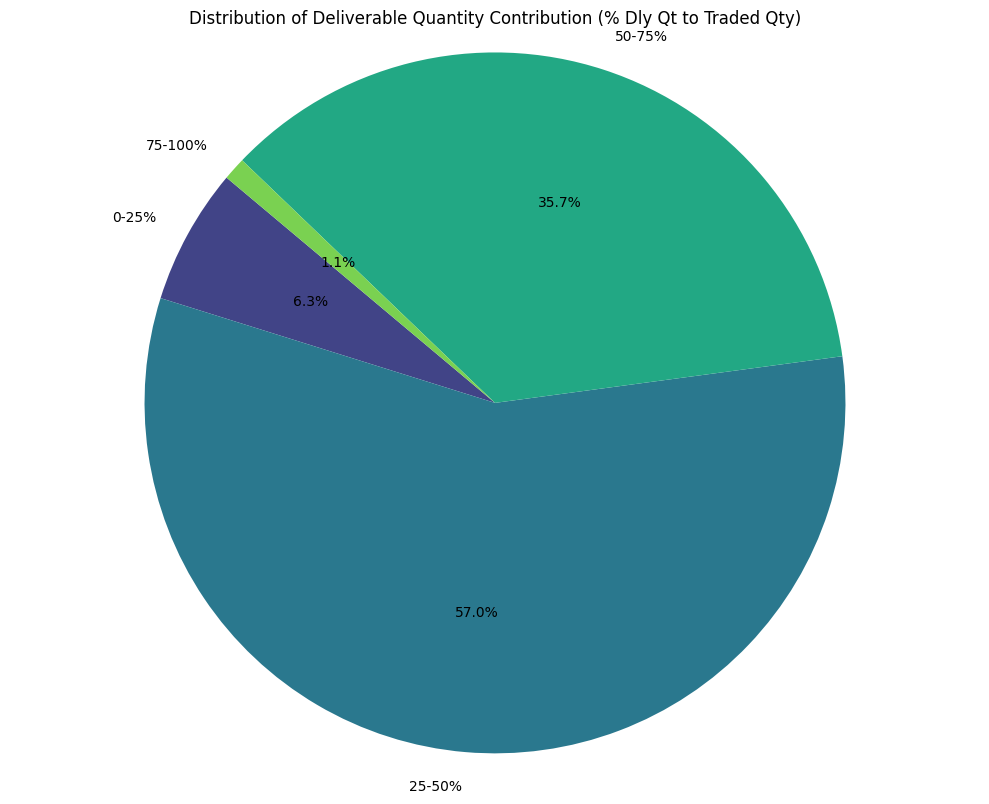

In [ ]:
# Define bins for '% Dly Qt to Traded Qty'
bins = [0, 25, 50, 75, 100]
labels = ['0-25%', '25-50%', '50-75%', '75-100%']

df['Dly_Qt_Category'] = pd.cut(df['% Dly Qt to Traded Qty'], bins=bins, labels=labels, right=False)

# Calculate the contribution of each category
category_counts = df['Dly_Qt_Category'].value_counts().sort_index()

plt.figure(figsize=(10, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(category_counts)))
plt.title('Distribution of Deliverable Quantity Contribution (% Dly Qt to Traded Qty)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

### Turnover vs Number of Trades

This bubble chart visualizes the relationship between 'No. of Trades', 'Turnover', and 'Total Traded Quantity'. It helps to identify if higher trades generally lead to higher turnover, with the size of the bubbles indicating the volume.

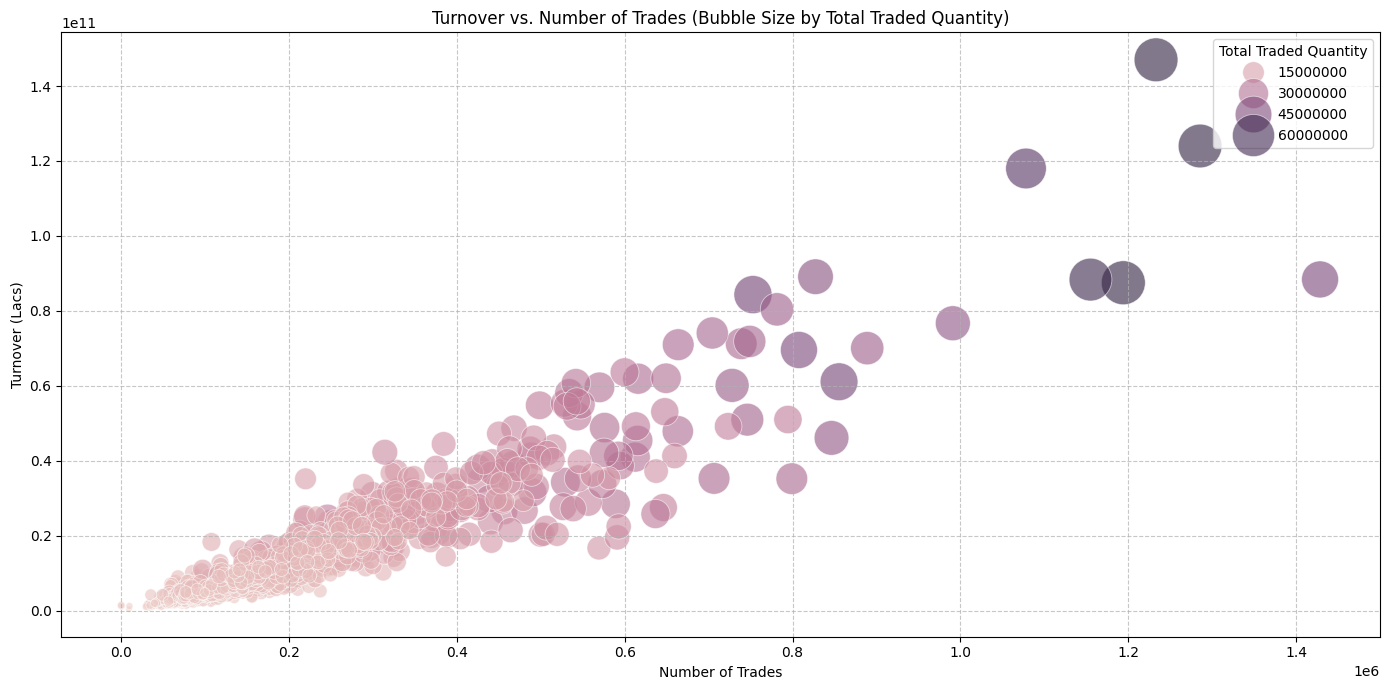

In [ ]:
plt.figure(figsize=(14, 7))
df.columns = df.columns.str.strip()
sns.scatterplot(x='No. of Trades', y='Turnover', size='Total Traded Quantity', data=df, sizes=(20, 1000), alpha=0.6, hue='Total Traded Quantity', legend='brief')
plt.title('Turnover vs. Number of Trades (Bubble Size by Total Traded Quantity)')
plt.xlabel('Number of Trades')
plt.ylabel('Turnover (Lacs)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 10. Correlation Between Variables

👉 **Insight**: Strong relationships exist between price-related fields.

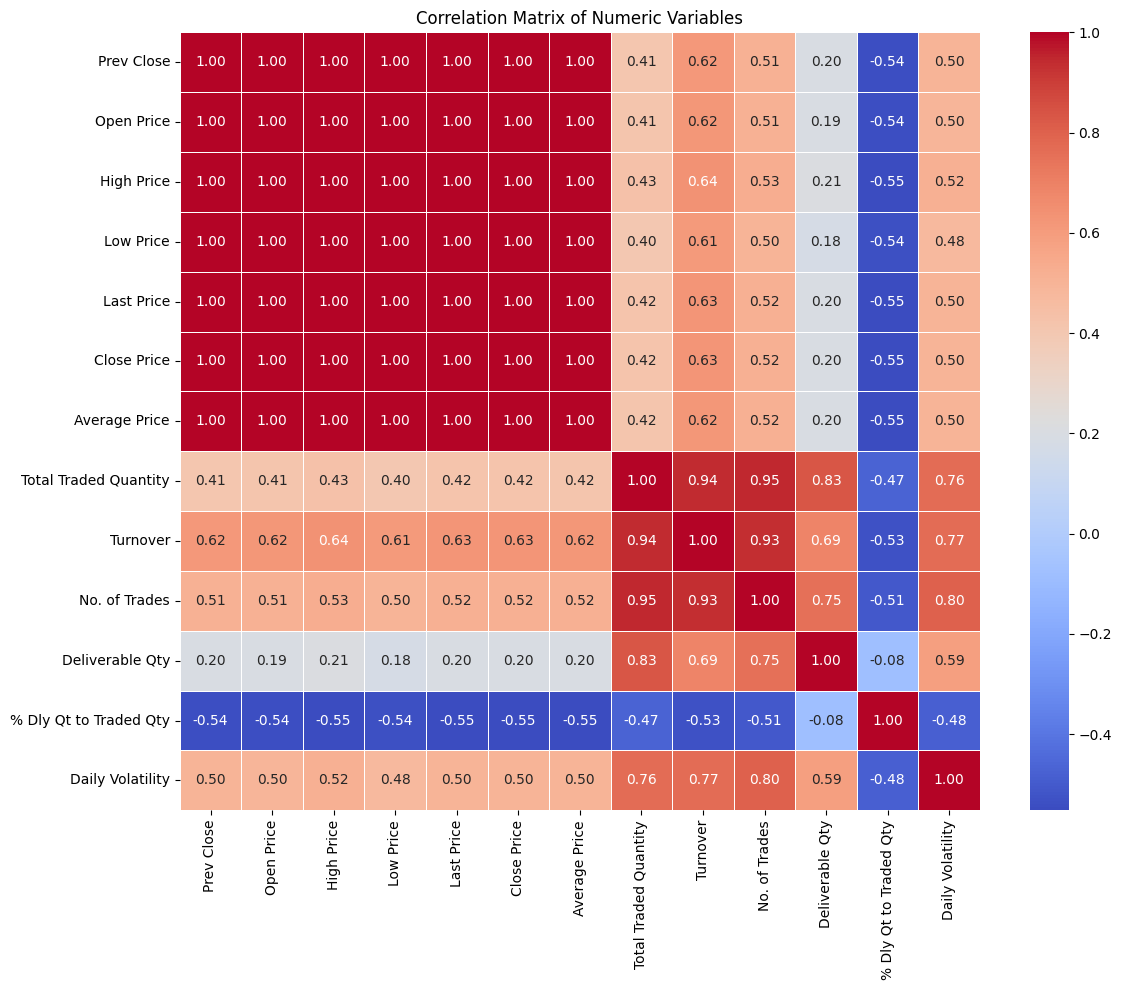

In [ ]:
# Select only numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()

### 9. Monthly Trading Activity

👉 **Insight**: Some months show higher activity than others.

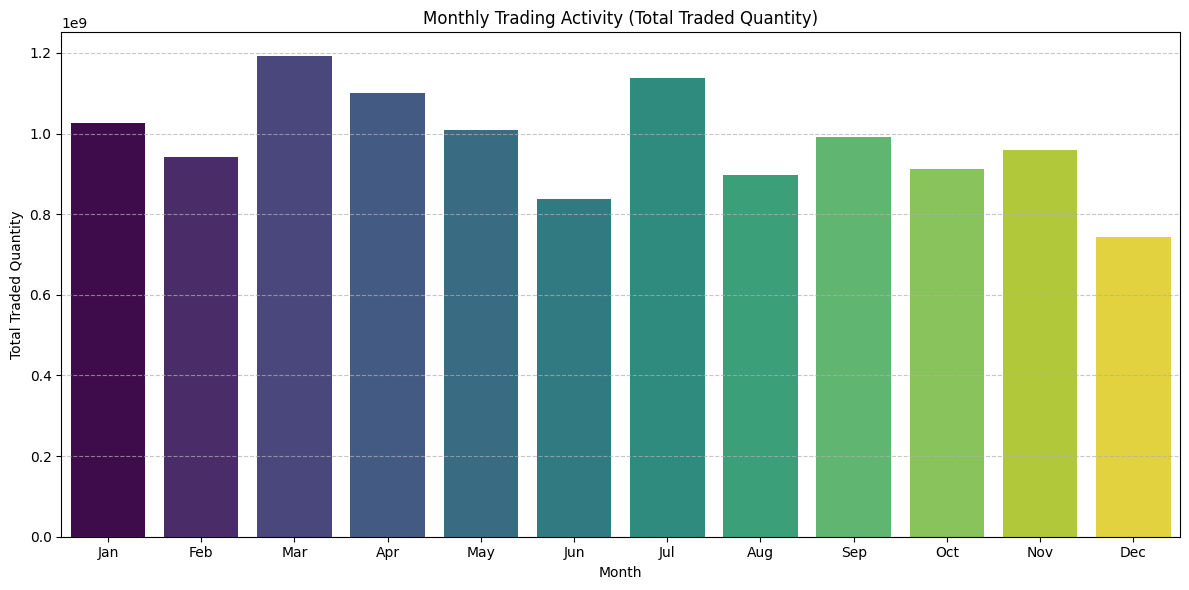

In [ ]:
# Extract month from 'Date' and aggregate 'Total Traded Quantity'
df['Month'] = df['Date'].dt.month
monthly_activity = df.groupby('Month')['Total Traded Quantity'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Month', y='Total Traded Quantity', data=monthly_activity, palette='viridis', hue='Month', legend=False)
plt.title('Monthly Trading Activity (Total Traded Quantity)')
plt.xlabel('Month')
plt.ylabel('Total Traded Quantity')
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 4. Price Movement Intensity Over Time

👉 **New Insight**: Instead of just correlation, show how aggressively price changes day-to-day

In [ ]:
# Install mplfinance for candlestick charts
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 1.6 MB/s eta 0:00:00


/tmp/ipykernel_18454/3308636105.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust rect to make space for suptitle


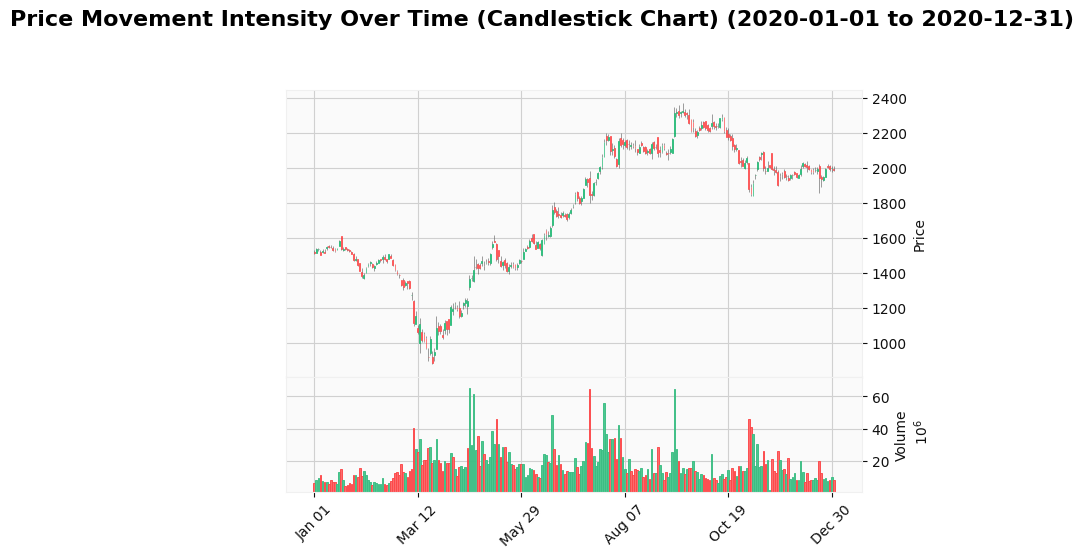

In [ ]:
import mplfinance as mpf

# Ensure 'Date' column is datetime and set as index, which is required by mplfinance
df['Date'] = pd.to_datetime(df['Date'])
df_indexed = df.set_index('Date')

# Define the date range for zooming in
start_date = '2020-01-01'
end_date = '2020-12-31'

# Filter the data for the specified date range
ohlc_data = df_indexed.loc[start_date:end_date, ['Open Price', 'High Price', 'Low Price', 'Close Price', 'Total Traded Quantity']]
ohlc_data.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

# Create the candlestick chart
fig, ax = mpf.plot(ohlc_data,
                   type='candle',
                   style='yahoo',
                   title=f'Candlestick Chart for Price Movement Intensity ({start_date} to {end_date})',
                   ylabel='Price',
                   volume=True, # Add volume subplot
                   ylabel_lower='Volume',
                   returnfig=True
                  )

# Customize title and labels if needed after mpf.plot
fig.suptitle(f'Price Movement Intensity Over Time (Candlestick Chart) ({start_date} to {end_date})', y=1.02, fontsize=16)

# Adjust layout to prevent labels from overlapping
fig.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust rect to make space for suptitle

plt.show()

Please review the column information above and let me know which numeric column you'd like to use for the histogram (Distribution of a Key Numeric Variable).

### Distribution of 'Close Price'

This histogram shows the frequency distribution of the 'Close Price' values, helping us understand the common price ranges and identify any skewness or outliers.